# Importing Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
import plotly.subplots as sp
from plotly.subplots import make_subplots
from matplotlib import rcParams
# from plotly.offline import init_notebook_mode
# init_notebook_mode(connected=True)
import plotly.express as px
import warnings
import time
import datetime as dt
warnings.filterwarnings("ignore")
from typing import Optional, Tuple, List, Any
from datasets import load_dataset
from datasets.utils.logging import disable_progress_bar
disable_progress_bar()

# Customizations

In [ ]:
class Print:
    """
    Colourful console output using ANSI escape codes.
    Provides methods for info, success, warning, error, etc.
    """
    _RESET = '\033[0m'
    _BOLD = '\033[1m'
    _DIVIDER = '=' * 70

    # ANSI colour codes
    _CYAN = '\033[96m'
    _GREEN = '\033[92m'
    _YELLOW = '\033[93m'
    _RED = '\033[91m'
    _MAGENTA = '\033[95m'
    _BLUE = '\033[94m'
    @classmethod
    def _print(cls, colour: str, symbol: str, *args, **kwargs):
        """Base print method with colour and symbol."""
        message = ' '.join(str(a) for a in args)
        print(f"{cls._BOLD}{colour}{symbol} {message}{cls._RESET}", **kwargs)

    @classmethod
    def info(cls, *args, **kwargs):
        cls._print(cls._CYAN, '[i]', *args, **kwargs)

    @classmethod
    def success(cls, *args, **kwargs):
        cls._print(cls._GREEN, '[✓]', *args, **kwargs)

    @classmethod
    def warning(cls, *args, **kwargs):
        cls._print(cls._YELLOW, '[!]', *args, **kwargs)

    @classmethod
    def error(cls, *args, **kwargs):
        cls._print(cls._RED, '[✗]', *args, **kwargs)

    @classmethod
    def header(cls, *args, **kwargs):
        """Print a section header with a divider."""
        print()
        cls._print(cls._MAGENTA, '---', *args, **kwargs)
        print(cls._DIVIDER)

    @classmethod
    def divider(cls):
        print(cls._DIVIDER)

    @classmethod
    def blank(cls):
        print()


In [ ]:
def print_table(df: pd.DataFrame, title: Optional[str] = None, max_rows: int = 20):
    """
    Display a styled DataFrame in Jupyter.
    """

    df_disp = df.head(max_rows).copy()

    # Detect column types
    num_cols = df_disp.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df_disp.select_dtypes(include=["object", "category"]).columns.tolist()

    styled = df_disp.style

    # Base Table Styling
    styled = styled.set_table_styles(
        [
            {
                "selector": "th",
                "props": [("background-color", "#2f3e46"),("color", "white"),("font-weight", "bold"),("text-align", "center"),("border", "1px solid #dddddd"),
                ],
            },
             {
                "selector": "td",
                "props": [("border", "1px solid #eeeeee"),("padding", "6px"),("text-align", "center"),
                ],
            },
            {
                "selector": "tr:hover",
                "props": [("background-color", "#f1f3f5")],
            },
        ]
    )
    # Numeric Styling
    if num_cols:
        styled = styled.background_gradient(
            cmap="Blues",
            subset=num_cols
        ).format(precision=3)

    # Categorical Styling
    if cat_cols:
        styled = styled.set_properties(
            subset=cat_cols,
            **{
                "background-color": "#fdf6e3",  # soft beige
                "color": "#333333",
            }
        )
        # Caption
    if title:
        styled = styled.set_caption(title).set_table_styles(
            [
                {
                    "selector": "caption",
                    "props": [
                        ("caption-side", "top"),
                        ("font-size", "16px"),
                        ("font-weight", "bold"),
                        ("padding", "8px"),
                    ],
                }
            ],
            overwrite=False,
        )

    display(styled)


In [ ]:
def set_plot_style():
    rcParams['figure.figsize'] = (12, 6)
    rcParams['axes.facecolor'] = '#f8f9fa'
    rcParams['figure.facecolor'] = 'white'
    rcParams['axes.grid'] = True
    rcParams['grid.alpha'] = 0.3
    rcParams['grid.color'] = '#cccccc'
    rcParams['axes.edgecolor'] = '#333333'
    rcParams['axes.linewidth'] = 1.2
    rcParams['font.family'] = 'sans-serif'
    rcParams['font.size'] = 11
    rcParams['axes.labelsize'] = 12
    rcParams['axes.titlesize'] = 14
    rcParams['axes.titleweight'] = 'bold'
    rcParams['xtick.labelsize'] = 10
    rcParams['ytick.labelsize'] = 10
    rcParams['legend.fontsize'] = 10
    rcParams['legend.framealpha'] = 0.9

    # Custom colour palette
      # Custom colour palette
    global COLORS
    COLORS = ['#1e3c72', '#c31432', '#9D4EDD', '#C77DFF', '#E0AAFF', '#5A189A', '#240046']

    # Set seaborn palette
    sns.set_palette(sns.color_palette(COLORS))

    # Apply to matplotlib
    plt.rcParams.update(rcParams)

# Importing Dataset

In [ ]:
! gdown 11uurHsNZAjG70Ooq0noI7a2W4rbiNvIw

Downloading...
From: https://drive.google.com/uc?id=11uurHsNZAjG70Ooq0noI7a2W4rbiNvIw
To: /content/combined_model_dataset.csv
100% 22.0M/22.0M [00:00<00:00, 105MB/s]


In [ ]:
df = pd.read_csv('/content/combined_model_dataset.csv')

In [ ]:
df

,text,label
0,"this is politicians' strategy\n\n""Action throu...",0
1,He has underlings to do tjat for him,0
2,"Judge on separation of immigrant families: ""if...",0
3,To the republican nra(Nazi's Razing America)th...,0
4,Somebody musta complained.,0
...,...,...
78949,Throw a little pesticide on top of carcinogen ...,0
78950,This man is a coward & an oath breaker & the w...,1
78951,A ProPublica investigation found that police r...,0
78952,You answered the question better than I could ...,0


# Data Preparation

## Text preprocessing

In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.8 MB/s eta 0:00:00


In [ ]:
 # remove punctuation (optional)
# text = re.sub(r'[^\w\s]', '', text)

In [ ]:
import re
import nltk
import contractions
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
stop_words = set(stopwords.words("english"))- {"not", "no"}
def preprocess(text):
  if not text or str(text).strip() == "":
    return ""
  # expand contractions
  text = contractions.fix(text)

  # lowercase
  text = text.lower()

  # remove mentions
  text = re.sub(r'@\w+', 'user', text)

  # remove hashtag symbol but keep word
  text = re.sub(r'#', '', text)

  # remove URLs
  text = re.sub(r'http\S+|www\S+', '', text)

  # remove black bars
  text = re.sub(r'█+', ' ', text)

  # remove extra spaces
  text = re.sub(r'\s+', ' ', text).strip()

  tokens = nltk.word_tokenize(text)

  tokens = [w for w in tokens if w not in stop_words]
  return " ".join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
df["text"] = df["text"].apply(preprocess)
df

,text,label
0,politicians ' strategy `` action non-action '',0
1,underlings tjat,0
2,judge separation immigrant families : `` hell ...,0
3,republican nra ( nazi 's razing america ) slau...,0
4,somebody musta complained .,0
...,...,...
78949,throw little pesticide top carcinogen laced sm...,0
78950,man coward & oath breaker & worst kind human i...,1
78951,propublica investigation found police responde...,0
78952,"answered question better could justmaybe , tha...",0


## Train Test Split

In [ ]:
X = df['text']
y = df['label']

In [ ]:
from sklearn.model_selection import train_test_split
X_tr, X_test, y_tr, y_test = train_test_split(X,y,test_size = 0.20, random_state = 42, stratify = y)
X_train, X_val, y_train, y_val = train_test_split(X_tr,y_tr,test_size = 0.25, random_state = 42, stratify = y_tr)

In [ ]:
X_train.shape

(47372,)

In [ ]:
X_test.shape

(15791,)

In [ ]:
X_val.shape

(15791,)

## Feature Engineering using TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(
    lowercase = True,
    stop_words = 'english',
    ngram_range = (1,2),
    min_df = 2,
    max_df = 0.95,
    max_features = 50000,
    token_pattern= r'(?u)\b[a-zA-Z]{2,}\b'

)
X_train = vectorizer.fit_transform(X_train)
X_val = vectorizer.transform(X_val)
X_test = vectorizer.transform(X_test)
print(X_train.shape)

(47372, 50000)


In [ ]:
# save indices
import joblib
joblib.dump(X_train, "X_train.pkl")
joblib.dump(X_val, "X_val.pkl")
joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_val, "y_val.pkl")
joblib.dump(y_test, "y_test.pkl")

['y_test.pkl']

## Dimensionality reduction using Truncated SVD

In [ ]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(
    n_components = 300,
    random_state = 42
)

X_train = svd.fit_transform(X_train)
X_val = svd.transform(X_val)
X_test = svd.transform(X_test)

print("Reduced shape:", X_train.shape)


Reduced shape: (47372, 300)


In [ ]:
X_train

array([[ 0.00255392, -0.00267193, -0.00131925, ..., -0.00060467,
        -0.00186106, -0.00392646],
       [ 0.02848162, -0.02463778, -0.01903611, ..., -0.00294338,
        -0.01670066, -0.02185449],
       [ 0.03788741, -0.05427734, -0.02102031, ...,  0.00630587,
        -0.01036617,  0.01493568],
       ...,
       [ 0.03053522, -0.04080507, -0.01747963, ...,  0.00641634,
        -0.00234145, -0.00232565],
       [ 0.06700971, -0.09716114,  0.11234194, ...,  0.00340674,
        -0.01980087,  0.01916772],
       [ 0.06524451, -0.06903817, -0.02799614, ..., -0.01613285,
        -0.00496309, -0.00097607]])

In [ ]:
X_train = pd.DataFrame(
    X_train,
    columns=[f"SVD_{i}" for i in range(X_train.shape[1])]
)
X_train

,SVD_0,SVD_1,SVD_2,SVD_3,SVD_4,SVD_5,SVD_6,SVD_7,SVD_8,SVD_9,...,SVD_290,SVD_291,SVD_292,SVD_293,SVD_294,SVD_295,SVD_296,SVD_297,SVD_298,SVD_299
0,0.002554,-0.002672,-0.001319,-0.001313,0.000233,0.000605,-0.001338,-0.000637,0.001510,-0.000695,...,0.002892,-0.000669,-0.001820,-0.001779,0.001358,0.002301,0.002168,-0.000605,-0.001861,-0.003926
1,0.028482,-0.024638,-0.019036,-0.032353,0.022331,0.007619,-0.015155,0.014825,-0.016071,-0.014862,...,0.003521,0.014162,-0.008000,0.015863,0.038201,0.012079,0.001333,-0.002943,-0.016701,-0.021854
2,0.037887,-0.054277,-0.021020,0.062595,-0.085130,0.110696,0.017173,-0.032228,-0.017228,-0.002255,...,-0.010569,-0.005654,-0.001296,-0.004301,0.000463,0.004418,0.000768,0.006306,-0.010366,0.014936
3,0.042709,-0.059601,-0.030265,-0.037011,0.025671,0.008645,-0.037272,0.020342,-0.012219,-0.008526,...,0.030543,-0.028895,0.016906,0.002731,-0.014932,-0.005888,-0.010335,0.034966,0.001024,0.006119
4,0.047168,-0.064926,-0.036266,-0.026730,0.022420,0.001392,-0.031648,0.010774,-0.000412,0.007301,...,-0.008471,0.013249,-0.015482,-0.000101,0.014631,-0.012554,-0.007901,0.031357,0.000419,0.014238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47367,0.527493,0.359805,-0.001829,0.054736,-0.073088,-0.099908,-0.049753,0.007358,-0.126574,0.039872,...,0.000995,-0.002661,0.005125,-0.004062,0.004270,-0.005069,-0.004758,0.004089,-0.002760,0.014285
47368,0.050446,-0.074672,0.115689,0.031723,-0.046415,0.069428,0.004412,0.013389,-0.021355,0.007922,...,-0.062785,-0.035079,-0.014336,0.023950,-0.002289,0.017832,0.028960,0.040196,-0.038179,-0.019939
47369,0.030535,-0.040805,-0.017480,0.101565,0.098974,0.005378,0.013198,-0.034698,-0.024136,-0.010255,...,-0.010337,-0.003928,0.003521,0.005196,-0.009177,-0.020886,0.000148,0.006416,-0.002341,-0.002326
47370,0.067010,-0.097161,0.112342,-0.025796,0.024368,-0.000582,-0.036928,0.006709,-0.018211,-0.014595,...,0.010401,0.033345,-0.002831,-0.001965,-0.009737,0.015321,0.005938,0.003407,-0.019801,0.019168


In [ ]:
X_val = pd.DataFrame(
    X_val,
    columns=[f"SVD_{i}" for i in range(X_val.shape[1])]
)
X_val

,SVD_0,SVD_1,SVD_2,SVD_3,SVD_4,SVD_5,SVD_6,SVD_7,SVD_8,SVD_9,...,SVD_290,SVD_291,SVD_292,SVD_293,SVD_294,SVD_295,SVD_296,SVD_297,SVD_298,SVD_299
0,0.041174,-0.057976,0.081446,-0.010771,0.013849,0.003793,-0.018403,0.017995,0.002497,-0.004160,...,-0.017884,0.012414,-0.008844,-0.019796,-0.002694,-0.005687,-0.015191,-0.015153,-0.005931,-0.004428
1,0.037441,-0.050612,-0.018692,-0.022335,0.012643,-0.010751,-0.017941,-0.042355,0.013881,-0.009813,...,0.003089,0.008680,-0.004122,0.001842,0.007514,-0.001207,-0.005488,-0.005129,0.007367,0.008482
2,0.013559,-0.020099,-0.010244,-0.002404,0.003858,-0.000416,-0.004731,-0.007284,-0.000773,0.000718,...,0.024130,-0.018111,0.011331,0.037119,0.022661,0.019026,0.023002,-0.021676,-0.014320,0.030472
3,0.013733,-0.016655,0.002746,-0.001001,-0.001706,-0.002593,-0.003493,-0.010391,0.004218,-0.001639,...,-0.000708,-0.000994,-0.014666,0.020099,-0.016517,0.008762,-0.006632,0.014826,0.025942,-0.008646
4,0.028483,-0.038945,-0.019495,-0.012048,0.010729,0.002780,-0.018734,0.002196,-0.004231,-0.005379,...,0.042047,-0.027281,0.005857,0.035321,0.007778,0.004396,0.068395,-0.026008,-0.022268,0.046367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15786,0.042889,-0.058521,-0.017625,0.001873,-0.006685,-0.045199,0.053224,-0.039828,0.018901,-0.073520,...,-0.004360,-0.008047,-0.003468,0.027197,0.008854,0.045887,-0.014470,-0.001864,0.004636,0.039319
15787,0.148089,0.090104,-0.000314,-0.003355,0.002409,0.003537,-0.003833,-0.004727,0.008072,-0.004403,...,0.012660,-0.000171,0.006414,0.029234,-0.014442,0.004822,-0.007990,0.006951,0.016973,0.009861
15788,0.030350,-0.036970,-0.025250,-0.005103,0.009624,-0.014474,-0.008650,0.023928,0.005222,0.013603,...,0.013843,0.004535,0.004758,-0.005757,-0.008855,-0.008148,0.004351,0.005164,-0.000801,-0.000477
15789,0.061704,-0.083183,0.063731,0.107060,0.104485,0.000433,0.001987,-0.009628,-0.019749,0.016133,...,0.004056,0.002298,0.002877,0.008370,0.006854,-0.004073,-0.000031,-0.001451,0.008901,0.009765


In [ ]:
X_test = pd.DataFrame(
    X_test,
    columns=[f"SVD_{i}" for i in range(X_test.shape[1])]
)
X_test

,SVD_0,SVD_1,SVD_2,SVD_3,SVD_4,SVD_5,SVD_6,SVD_7,SVD_8,SVD_9,...,SVD_290,SVD_291,SVD_292,SVD_293,SVD_294,SVD_295,SVD_296,SVD_297,SVD_298,SVD_299
0,0.069213,-0.095159,0.003501,0.014114,-0.051139,0.042948,0.065068,0.033784,-0.003260,0.016010,...,-0.017573,-0.018274,-0.026092,-0.011489,0.012845,-0.034032,-0.012610,-0.008900,0.027948,-0.017076
1,0.056932,-0.075662,-0.035897,-0.033610,0.001326,-0.028906,0.033509,0.030671,-0.016408,0.002210,...,-0.018709,0.004958,0.013360,-0.021335,0.028662,0.031239,-0.022904,-0.013606,-0.013401,0.028812
2,0.052092,-0.071983,0.015072,-0.019305,0.002019,-0.029008,-0.013870,-0.059015,0.003149,-0.006806,...,-0.009081,0.008583,-0.009994,-0.006114,-0.015036,0.020595,-0.016263,0.001676,0.015461,0.004329
3,0.092855,-0.125781,0.083514,0.016704,-0.052772,0.066376,-0.013615,-0.026057,-0.014205,-0.027203,...,0.007405,0.003754,0.006617,-0.023947,0.027046,0.006523,0.029435,0.041579,-0.027417,-0.014887
4,0.066509,-0.058374,-0.039395,0.040435,-0.067546,-0.114717,-0.062191,0.015986,-0.082776,0.004630,...,0.009798,-0.024535,-0.003056,0.011755,-0.023302,-0.017544,-0.006797,0.005147,-0.022951,0.003669
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15786,0.016463,-0.021420,-0.008292,-0.005963,0.001121,-0.000891,-0.009122,-0.004755,0.000988,-0.002444,...,-0.000808,-0.021515,-0.014392,-0.003853,0.005328,-0.007217,0.016758,-0.009059,0.005386,-0.002025
15787,0.034377,-0.047521,-0.006820,-0.006403,0.007714,0.000541,-0.018541,-0.050339,0.010279,-0.023536,...,-0.015126,0.015867,-0.006635,0.040601,0.020519,-0.007358,0.012779,0.018275,0.003649,-0.012052
15788,0.019810,-0.029040,-0.008910,0.004587,0.003336,-0.005944,-0.004948,-0.036956,0.014254,0.001497,...,-0.011044,0.022957,0.011466,-0.005408,0.003387,0.002031,0.010179,-0.002288,-0.007012,0.010268
15789,0.054190,-0.075180,-0.031395,0.052733,-0.074967,0.098642,0.004289,-0.039401,-0.003026,0.034531,...,-0.026042,-0.022801,-0.028095,-0.005973,-0.026975,-0.047744,-0.027153,0.017399,-0.008896,-0.001820


# Hyperparameter tuning using Optuna

In [ ]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 32.8 MB/s eta 0:00:00


In [ ]:
import optuna
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import f1_score

In [ ]:
def objective(trial):
  max_depth = trial.suggest_int('max_depth',3,10)
  num_leaves = trial.suggest_int('num_leaves',8, min(2**max_depth,256))
  params = {
      "objective": "binary",
      "metric":"binary_logloss",
      "boosting_type": "gbdt",
      "n_estimators": trial.suggest_int('n_estimators',500,3000),
      "learning_rate": trial.suggest_float('learning_rate',1e-3,0.1, log=True),
      "max_depth": max_depth,
      "num_leaves": num_leaves,
      "min_child_samples": trial.suggest_int("min_child_samples",5,50),
      "subsample": trial.suggest_float("subsample", 0.6,1.0),
      "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6,1.0),
      "reg_alpha": trial.suggest_float("reg_alpha",1e-4, 10.0, log=True),
       "reg_lambda": trial.suggest_float("reg_lambda",1e-4, 10.0, log=True),
      "random_state":42,
      "n_jobs":-1,
      "verbosity":-1

  }

  model = LGBMClassifier(**params)
  model.fit(X_train,
            y_train,
            eval_set = [(X_val, y_val)],
            eval_metric = 'binary_logloss',
            callbacks = [
                early_stopping(stopping_rounds = 50, verbose = False),
                log_evaluation(period = 0)
            ]
            )
  y_pred = model.predict(X_val)
  f1 = f1_score(y_val,y_pred)
  return f1

In [ ]:
study = optuna.create_study(direction = "maximize", study_name = "lgbmclassifier_optuna", sampler = optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials = 50)

[I 2026-04-08 20:45:51,716] A new study created in memory with name: lgbmclassifier_optuna
[I 2026-04-08 20:46:19,698] Trial 0 finished with value: 0.7398931067562011 and parameters: {'max_depth': 5, 'num_leaves': 31, 'n_estimators': 2330, 'learning_rate': 0.015751320499779727, 'min_child_samples': 12, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 2.1423021757741068, 'reg_lambda': 0.10129197956845731}. Best is trial 0 with value: 0.7398931067562011.
[I 2026-04-08 20:46:55,633] Trial 1 finished with value: 0.7446141259885465 and parameters: {'max_depth': 8, 'num_leaves': 13, 'n_estimators': 2925, 'learning_rate': 0.04622589001020832, 'min_child_samples': 14, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.6733618039413735, 'reg_alpha': 0.0033205591037519565, 'reg_lambda': 0.042051564509138675}. Best is trial 1 with value: 0.7446141259885465.
[I 2026-04-08 20:47:27,490] Trial 2 finished with value: 0.6938321396286767 and parameters: {'max_dep

In [ ]:
print('Number of finished trials: ', len(study.trials))
trial = study.best_trial
print('Best Trial: ')
print('Value: ', trial.value)
print('Params: ')
for key, value in trial.params.items():
  print(f'    {key}: {value}')

Number of finished trials:  50
Best Trial: 
Value:  0.7499830565909861
Params: 
    max_depth: 8
    num_leaves: 77
    n_estimators: 1390
    learning_rate: 0.05966554425263609
    min_child_samples: 24
    subsample: 0.9831904699630575
    colsample_bytree: 0.8890237037952976
    reg_alpha: 0.020795016849995986
    reg_lambda: 9.792371237419218


In [ ]:
params = study.best_params
params.update({
    "objective": "binary",
    "metric": "binary_logloss",
    "boosting_type": "gbdt",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1
})
params

{'max_depth': 8,
 'num_leaves': 77,
 'n_estimators': 1390,
 'learning_rate': 0.05966554425263609,
 'min_child_samples': 24,
 'subsample': 0.9831904699630575,
 'colsample_bytree': 0.8890237037952976,
 'reg_alpha': 0.020795016849995986,
 'reg_lambda': 9.792371237419218,
 'objective': 'binary',
 'metric': 'binary_logloss',
 'boosting_type': 'gbdt',
 'random_state': 42,
 'n_jobs': -1,
 'verbosity': -1}

In [ ]:
final_model = LGBMClassifier(**params)
final_model.fit(X_train,
          y_train)

LGBMClassifier(colsample_bytree=0.8890237037952976,
               learning_rate=0.05966554425263609, max_depth=8,
               metric='binary_logloss', min_child_samples=24, n_estimators=1390,
               n_jobs=-1, num_leaves=77, objective='binary', random_state=42,
               reg_alpha=0.020795016849995986, reg_lambda=9.792371237419218,
               subsample=0.9831904699630575, verbosity=-1)

In [ ]:
y_pred = final_model.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 1, 0])

In [ ]:
# validation dataset
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
y_val_pred = final_model.predict(X_val)
print("Accuarcy:",accuracy_score(y_val, y_val_pred))
print("Precision:",precision_score(y_val, y_val_pred))
print("Recall:",recall_score(y_val, y_val_pred))
print("f1 score:",f1_score(y_val, y_val_pred))

Accuarcy: 0.7659426255461972
Precision: 0.7881067272211184
Recall: 0.7159618359979371
f1 score: 0.7503040129712201


In [ ]:
# Test dataset
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score
print("Accuarcy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("f1 score:",f1_score(y_test, y_pred))
print("ROC-AUC score of Naive Bayes Classifier", roc_auc_score(y_test, y_pred))

Accuarcy: 0.769868912671775
Precision: 0.7912367491166078
Recall: 0.7218568665377176
f1 score: 0.754956169925826
ROC-AUC score of Naive Bayes Classifier 0.769029478565026


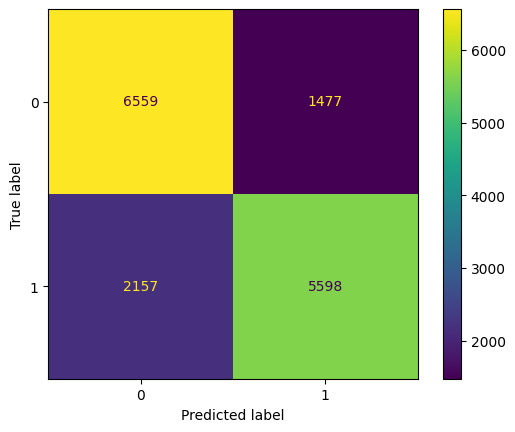

In [ ]:
# Confusion matrix
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
sns.reset_orig()
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=final_model.classes_)
disp.plot()

In [ ]:
# Classifiaction report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78      8036
           1       0.79      0.72      0.75      7755

    accuracy                           0.77     15791
   macro avg       0.77      0.77      0.77     15791
weighted avg       0.77      0.77      0.77     15791



In [ ]:
# Saving model using pickle
import pickle
import os

model_path = "/content/LightGBM_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(final_model, f)

print("Model saved at:", model_path)
print("File exists:", os.path.exists(model_path))

Model saved at: /content/LightGBM_model.pkl
File exists: True


# Assessment
**Why this model was chosen**
- LightGBM was chosen for its ability to handle non-linear relationships and capture interactions between features.
- It is efficient and performs well on large datasets after dimensionality reduction.

**Model assumptions**
- Does not assume linearity
- Uses gradient boosting decision trees
- Works better with dense features
- Therefore, TF-IDF features were reduced using Truncated SVD before training.

**Hyperparameter tuning**
- Used Optuna to tune:
  - n_estimators
  - learning_rate
  - max_depth, num_leaves
  - subsample, colsample_bytree
  - reg_alpha, reg_lambda
- Also applied:
  - early stopping
  - validation-based tuning

**Challenges & solutions**

$$
\begin{array}{|l|l|}
\hline
\textbf{Challenge} & \textbf{Solution} \\
\hline
\text{High dimensional TF-IDF caused instability} & \text{Applied SVD (200–250 components)} \\
\hline
\text{F1 score instability} & \text{Used probability threshold tuning and proper validation} \\
\hline
\end{array}
$$